<style>
pre {
    white-space: pre-wrap !important;
    word-wrap: break-word !important;
    overflow-wrap: anywhere !important;
}

.highlight pre {
    white-space: pre-wrap !important;
}

.jp-CodeCell .jp-InputArea-editor {
    white-space: pre-wrap !important;
}
</style>


<style>
@media print {

    @page {
        size: A4 portrait;
        margin: 0.5cm;
    }

    /* Quitar límites de ancho de VS Code/Jupyter */
    body,
    main,
    .jp-Notebook,
    .jp-NotebookPanel,
    .jp-NotebookPanel-notebook {
        width: 100% !important;
        max-width: none !important;
        margin: 0 !important;
        padding: 0 !important;
    }

    /* Evitar que los contenedores corten las tablas */
    .jp-Cell,
    .jp-Cell-outputWrapper,
    .jp-OutputArea,
    .jp-OutputArea-child,
    .jp-OutputArea-output,
    .jp-RenderedHTMLCommon {
        width: 100% !important;
        max-width: none !important;
        overflow: visible !important;
        overflow-x: visible !important;
    }

    /* FORZAR tablas de pandas a caber */
    table.dataframe {
        zoom: 0.60 !important;
        font-size: 9px !important;
        width: 100% !important;
        max-width: none !important;
        table-layout: auto !important;
        border-collapse: collapse !important;
    }

    table.dataframe th,
    table.dataframe td {
        padding: 2px 4px !important;
        white-space: normal !important;
        word-break: normal !important;
        overflow-wrap: anywhere !important;
    }

    /* Gráficas */
    img,
    svg {
        max-width: 100% !important;
        height: auto !important;
    }
}
</style>

<style>
@media print {

    @page {
        size: A4 portrait;
        margin: 0.5cm;
    }

    /* Aprovechar todo el ancho de la hoja */
    body {
        margin: 0 !important;
        padding: 0 !important;
    }

    .jp-Notebook,
    .jp-NotebookPanel-notebook,
    .notebook_app,
    #notebook-container {
        width: 100% !important;
        max-width: 100% !important;
        margin: 0 !important;
        padding: 0 !important;
    }

    /* Evitar que VS Code corte las salidas */
    .jp-OutputArea,
    .jp-OutputArea-output,
    .output_area,
    .output_subarea {
        width: 100% !important;
        max-width: 100% !important;
        overflow: visible !important;
    }

    /* Tablas */
    table.dataframe {
        width: 100% !important;
        max-width: 100% !important;
        table-layout: fixed !important;
        font-size: 6px !important;
        border-collapse: collapse !important;
    }

    table.dataframe th,
    table.dataframe td {
        padding: 1px 2px !important;
        white-space: normal !important;
        overflow-wrap: anywhere !important;
        word-break: break-word !important;
        text-align: center !important;
    }

    /* Que las imágenes/gráficas tampoco se salgan */
    img {
        max-width: 100% !important;
        height: auto !important;
    }
}
</style>

<style>
@media print {

    @page {
        size: A4 portrait;
        margin: 0.8cm;
    }

    /* Tablas normales */
    table.dataframe {
        font-size: 10px !important;
        width: 100% !important;
        border-collapse: collapse !important;
    }

    table.dataframe th,
    table.dataframe td {
        padding: 3px 5px !important;
        white-space: normal !important;
        overflow-wrap: anywhere !important;
        text-align: center !important;
    }

    /* Solo tablas muy anchas */
    table.dataframe:has(th:nth-child(9)) {
        zoom: 0.80 !important;
    }

    table.dataframe:has(th:nth-child(12)) {
        zoom: 0.68 !important;
    }

    table.dataframe:has(th:nth-child(15)) {
        zoom: 0.58 !important;
    }

    /* Evitar recortes */
    .jp-OutputArea,
    .jp-OutputArea-output,
    .jp-RenderedHTMLCommon {
        max-width: 100% !important;
        overflow: visible !important;
    }

    img, svg {
        max-width: 100% !important;
        height: auto !important;
    }
}
</style>

<h1 style="text-align: center;">Calificaciones</h1>

## Introducción
El análisis de datos y el aprendizaje automático permiten identificar patrones y realizar predicciones. En este reporte se analiza un conjunto de datos sobre estudiantes que incluye variables como edad, horas de estudio, faltas, materias reprobadas y calificaciones de distintos periodos. 

El objetivo de este reporte es estudiar y analizar la relación entre estas características y la calificación final, utilizando un modelo de regresión lineal múltiple. Para esto, se realiza una exploración de los datos, se limpian y se transforman algunas variables categóricas a un formato numérico. Además, se realiza una revisión de valores faltantes y duplicados, y valores atípicos.

Posteriormente, se aplican métodos de selección de características para identificar las variables que mejor aporten información para la predicción de la calificación final. Finalmente, se entrenan y se comparan modelos utilizando datos de entrenamiento y prueba, principalmente para evitar la fuga de datos. Esto de manera que la evaluación final permita estimar de una manera correcta la capacidad del modelo para realizar predicciones sobre nuevas observaciones.

## Exploración del conjunto de datos
Primero se cargó el conjunto de datos utilizando la base de datos "A1.3 Calificaciones" y se eliminaron posibles registros duplicados. Después de este procedimiento, la base de datos quedó conformada por 392 observaciones y 10 variables. La variable de salida seleccionada fue G3, es decir, la calificación final del estudiante. 

El conjunto de datos contiene variables tanto cuantitativas como cualitativas. De acuerdo con la descripción del conjunto de datos, la variable HorasDeEstudio se representa con valores del 1 al 4, donde cada valor corresponde a un intervalo de horas de estudio semanal: 1 es igual a menos de 2 horas, 2 es igual a entre 2 y 5 horas, 3 entre 5 y 10 horas, y 4 es más de 10 horas (Cortez, 2008). Por esta razón, aunque se encuentre representada con números, es una variable ordinal, ya que sus valores se definen en categorías. Las variables cualitativas son Escuela, Sexo e Internet, mientras que las variables cuantitativas son Edad, Reprobadas, Faltas, G1, G2 y G3.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("A1.3 Calificaciones.csv")
data = data.drop_duplicates().reset_index(drop=True)
data.head(10).style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th','props': [('text-align', 'center')]}]).set_caption("[TABLA 1]. Primeros 10 registros de la base de datos.")

Escuela,Sexo,Edad,HorasDeEstudio,Reprobadas,Internet,Faltas,G1,G2,G3
GP,F,18,2,0,no,6,5,6,6
GP,F,17,2,0,yes,4,5,5,6
GP,F,15,2,3,yes,10,7,8,10
GP,F,15,3,0,yes,2,15,14,15
GP,F,16,2,0,no,4,6,10,10
GP,M,16,2,0,yes,10,15,15,15
GP,M,16,2,0,yes,0,12,12,11
GP,F,17,2,0,no,6,6,5,6
GP,M,15,2,0,yes,0,16,18,19
GP,M,15,2,0,yes,0,14,15,15


### Información general del conjunto de datos
La Tabla 2 presenta la información general de las variables incluidas en el conjunto de datos. Se observa que Escuela, Sexo e Internet son de tipo string, mientras que Edad, Reprobadas, Faltas G1, G2, G3 y HorasDeEstudio son de tipo entero. Además, las 10 variables cuentan con 392 datos no nulos y ningún valor faltante, por lo que no se necesitó realizar un proceso de imputación o eliminación.

In [72]:
info_tabla = pd.DataFrame({"Variable": data.columns,"Tipo de dato": data.dtypes.astype(str).values,"Datos no nulos": data.notnull().sum().values,"Datos nulos": data.isnull().sum().values})
(info_tabla.style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]).set_caption("[TABLA 2]. Información general del conjunto de datos."))

Variable,Tipo de dato,Datos no nulos,Datos nulos
Escuela,str,392,0
Sexo,str,392,0
Edad,int64,392,0
HorasDeEstudio,int64,392,0
Reprobadas,int64,392,0
Internet,str,392,0
Faltas,int64,392,0
G1,int64,392,0
G2,int64,392,0
G3,int64,392,0


### Descripción estadística
La descripción estadística permitió observar el comportamiento general de las variables numéricas. 

La edad de los estudiantes se encuentra en 15 y 22 años, con una media de 16.7 años. Las calificaciones G1, G2 y G3 tienen valores promedios cercanos a 11 puntos, mientras que la calificación final G3 se encuentra dentro de un rango de 0 a 20 puntos.

La variable Faltas, presentó un comportamiento diferente al resto. Su promedio fue de 5.72 faltas, con una desviación estándar de 8.02, mientras que su valor máximo alcanzó 75 faltas. Esta diferencia respecto al comportamiento general, indicó la necesidad de revisar con mayor detalle la presencia de posibles valores atípicos.

In [73]:
data.describe().style.set_caption("[TABLA 3.] Descripción estadística del conjunto de datos")

,Edad,HorasDeEstudio,Reprobadas,Faltas,G1,G2,G3
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,16.696429,2.035714,0.336735,5.721939,10.905612,10.706633,10.420918
std,1.278261,0.842448,0.745920,8.023414,3.322214,3.766613,4.558107
min,15.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,1.000000,0.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,2.000000,0.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,2.000000,0.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,3.000000,75.000000,19.000000,19.000000,20.000000


## Separación de datos en prueba y entrenamiento
Antes de realizar la limpieza y la selección de características, los datos fueron divididos aleatoriamente en dos conjuntos. El 80% de las observaciones (313 estudiantes), se utilizó para entrenamiento, mientras que el 20% restante (79 estudiantes), se utilizó para las pruebas. 

Se usó una semilla aleatoria de 27 para que la división pudiera reproducirse. Esta separación se realizó antes de las principales transformaciones para evitar la fuga de datos en la construcción del modelo. 

In [74]:
np.random.seed(27)
indices = np.random.permutation(len(data))
corte = int(len(data) * 0.80)
indices_train = indices[:corte]
indices_test = indices[corte:]
train = data.iloc[indices_train].copy()
test = data.iloc[indices_test].copy()
print("Entrenamiento:", train.shape)
print("Prueba:", test.shape)

Entrenamiento: (313, 10)
Prueba: (79, 10)


### Revisión de outliers (en datos de prueba)

Para identificar posibles valores atípicos se utilizó el método de Tukey, calculando el primer cuartil, tercer cuartil y rango intercuartílico de cada variable utilizando únicamente los datos de entrenamiento. 

El método identificó posibles valores atípicos en Edad, HorasDeEstudio, Reprobadas, Faltas y G2, mostrado en la Tabla 4. Sin embargo, esto no significa necesariamente que el dato sea incorrecto. Por ejemplo, la edad de 22 años o una calificación de 0 pueden ser datos poco frecuentes pero posibles dentro del conjunto de datos.

En el caso de la variable Reprobadas, el primer y tercer cuartil fueron iguales a cero, por lo que el rango intercuartílico también fuera cero y que cualquier estudiante con al menos una materia reprobada fuera categorizado como un outlier. Por lo que no sería adecuado eliminar estos registros solamente tomando en cuenta este criterio. 

La variable que presentó el comportamiento más extremo fue Faltas, donde se encontraron 13 posibles valores atípicos y observaciones superiores al comportamiento general de los datos. Por esta razón, esta variable fue tratada durante la limpieza de los datos.

In [75]:
variables_numericas = train.select_dtypes(include="number").columns
resultados = []

for variable in variables_numericas:
    Q1 = train[variable].quantile(0.25)
    Q3 = train[variable].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = train[(train[variable] < limite_inferior) | (train[variable] > limite_superior)]
    resultados.append({"Variable": variable,"Límite inferior": limite_inferior,"Límite superior": limite_superior,"Outliers": len(outliers)})

tabla_outliers = pd.DataFrame(resultados)
(tabla_outliers.style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th','props': [('text-align', 'center')]}]).set_caption("[TABLA 4]. Identificación de posibles valores atípicos en los datos de entrenamiento mediante el método de Tukey."))

Variable,Límite inferior,Límite superior,Outliers
Edad,13.000000,21.000000,1
HorasDeEstudio,-0.500000,3.500000,24
Reprobadas,0.000000,0.000000,67
Faltas,-12.000000,20.000000,13
G1,-1.000000,23.000000,0
G2,1.500000,21.500000,11
G3,-1.000000,23.000000,0


### Revisión de valores únicos (en datos de prueba)
La Tabla 5 muestra los valores únicos presentes en las variables numéricas del conjunto de entrenamiento. Las variables correspondientes a las calificaciones presentan una variedad de valores. G1 cuenta con 17 valores distintos, G2 tiene 16 y G3 tiene 18. Además, G2 y G3 cuentan con calificaciones iguales a 0, mientras que el valor mínimo observado para G1 es 3.

G3 solo puede tomar valores enteros en el conjunto de datos, mientras que los modelos de regresión lineal generan predicciones que típicamente incluyen valores decimales. Debido a esto, puede ser difícil que el modelo prediga exactamente una de las calificaciones observadas. 

Esta revisión de valores únicos permite conocer la distribución de los datos antes de limpiarlos y entrenar el modelo.

In [77]:
tabla_valores = pd.DataFrame({"Variable": ["Edad","HorasDeEstudio","Reprobadas","G1","G2","G3"],
    "Valores únicos": [", ".join(map(str, sorted(train.Edad.unique()))),", ".join(map(str, sorted(train.HorasDeEstudio.unique()))),", ".join(map(str, sorted(train.Reprobadas.unique()))),", ".join(map(str, sorted(train.G1.unique()))),", ".join(map(str, sorted(train.G2.unique()))),", ".join(map(str, sorted(train.G3.unique())))],
    "Cantidad de valores únicos": [train.Edad.nunique(),train.HorasDeEstudio.nunique(),train.Reprobadas.nunique(),train.G1.nunique(),train.G2.nunique(),train.G3.nunique()]})
(tabla_valores.style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]).set_caption("[TABLA 5]. Valores posibles de las variables numéricas en los datos de entrenamiento."))

Variable,Valores únicos,Cantidad de valores únicos
Edad,"15, 16, 17, 18, 19, 20, 21, 22",8
HorasDeEstudio,"1, 2, 3, 4",4
Reprobadas,"0, 1, 2, 3",4
G1,"3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19",17
G2,"0, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19",16
G3,"0, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20",18


## Limpieza de datos

Para reducir el efecto de valores altos en Faltas sin eliminar observaciones completas, se utilizó como referencia el percentil 99 de los datos de entrenamiento. Los valores superiores al límite obtenido fueron ajustados al valor máximo entero dentro del límite. Este ajuste permitió conservar a los estudiantes dentro del conjunto de datos, pero se reduce el efecto que podían tener estos valores extremos en el modelo de regresión.

Cabe destacar que el límite fue calculado con los datos de entrenamiento. Posteriormente, este mismo límite fue aplicado a los datos de prueba para evitar usar información del conjunto de prueba durante la preparación del modelo. 

Después se transformaron las variables cualitativas Escuela, Sexo, Internet y HorasDeEstudio mediante variables dummy con valores de 0 y 1. Esta transformación fue necesaria porque el modelo de regresión lineal trabaja con valores numéricos y no puede utilizar directamente categorías almacenadas como texto o etiquetas. Para cada variable se eliminó una categoría de referencia, con el fin de evitar tener información redundante en el modelo. 

Como resultado de esta transformación se generaron variables binarias como Escuela_MS, Sexo_M, Internet_yes, HorasDeEstudio_2, HorasDeEstudio_3 y HorasDeEstudio_4, esto se observa claramente en la Tabla 6. Escuela_MS toma el valor 1 cuando el estudiante pertenece a la escuela MS y 0 cuando pertenece a la escuela GP, Sexo_M toma el valor 1 cuando el estudiante es de sexo masculino y 0 cuando es femenino, e Internet_yes tiene el valor 1 cuando el estudiante tiene acceso a internet y 0 cuando no lo tiene. En cuanto a las categorías de HorasDeEstudio, se indica si el estudiante pertenece a cada una de esas categorías utilizando 1 para señalar pertenencia y 0 para señalar que no pertenece a la misma. 

Después de la limpieza, el conjunto de datos de entrenamiento mantuvo sus 313 observaciones con 12 columnas, incluyendo la variable G3. El conjunto de prueba conservó sus 79 observaciones con 12 columnas y se verificó nuevamente que no existieran valores nulos, esto se representa en las Tablas 7 y 8.

Asimismo, para verificar que las características tuvieran un tipo de dato adecuado para utilizar en el modelo de regresión, se elaboró la Tabla 9. Donde se observa que las variables previamente cualitativas, se transformaron a valores númericos enteros. Esta verificación de datos permitió confirmar que, después de la limpueza, no quedaron variables almacenadas como texto y que las variables se mantuvieran en un formato númerico.

In [115]:
train_limpio = train.copy()
test_limpio = test.copy()

# Calcular el límite de Faltas SOLO con entrenamiento
limite_percentil = train_limpio["Faltas"].quantile(0.99)
limite_faltas = train_limpio.loc[train_limpio["Faltas"] <= limite_percentil,"Faltas"].max()

# Aplicar el MISMO límite a train y test
train_limpio["Faltas"] = train_limpio["Faltas"].clip(upper=limite_faltas).astype(int)
test_limpio["Faltas"] = test_limpio["Faltas"].clip(upper=limite_faltas).astype(int)

columnas_categoricas = ["Escuela","Sexo","Internet","HorasDeEstudio"]
train_limpio = pd.get_dummies(train_limpio,columns=columnas_categoricas,drop_first=True,dtype=int)
test_limpio = pd.get_dummies(test_limpio,columns=columnas_categoricas,drop_first=True,dtype=int)
test_limpio = test_limpio.reindex(columns=train_limpio.columns,fill_value=0)
(train_limpio.head(10).style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]).set_caption("[TABLA 6]. Vista previa de los datos de entrenamiento después de la limpieza."))

Edad,Reprobadas,Faltas,G1,G2,G3,Escuela_MS,Sexo_M,Internet_yes,HorasDeEstudio_2,HorasDeEstudio_3,HorasDeEstudio_4
16,0,16,10,12,11,0,1,1,1,0,0
15,0,0,12,15,15,0,1,1,0,0,0
18,0,21,17,18,18,0,0,1,1,0,0
18,0,4,15,14,14,0,0,1,0,0,1
18,0,2,8,8,10,1,0,1,0,1,0
15,0,10,7,6,6,0,0,1,1,0,0
18,0,4,8,9,10,1,0,1,1,0,0
15,0,2,15,14,15,0,0,1,0,1,0
19,1,38,13,11,11,0,0,1,0,1,0
15,3,0,6,7,0,0,0,1,1,0,0


In [116]:
resumen_limpieza = pd.DataFrame({"Aspecto": ["Valores nulos","Filas duplicadas","Número de observaciones","Número de variables"],
    "Resultado": [train_limpio.isnull().sum().sum(),train_limpio.duplicated().sum(),train_limpio.shape[0],train_limpio.shape[1]]})
(resumen_limpieza.style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]).set_caption("[TABLA 7]. Verificación final de la limpieza de los datos de entrenamiento."))

Aspecto,Resultado
Valores nulos,0
Filas duplicadas,0
Número de observaciones,313
Número de variables,12


In [117]:
resumen_test = pd.DataFrame({"Aspecto": ["Valores nulos","Número de observaciones","Número de variables"],
    "Resultado": [test_limpio.isnull().sum().sum(),test_limpio.shape[0],test_limpio.shape[1]]})
(resumen_test.style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]).set_caption("[TABLA 8]. Verificación de los datos de prueba después de la preparación."))

Aspecto,Resultado
Valores nulos,0
Número de observaciones,79
Número de variables,12


In [118]:
tabla_tipos = pd.DataFrame({"Variable": train_limpio.columns,"Tipo de dato": train_limpio.dtypes.astype(str).values})
(tabla_tipos.style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]).set_caption("[TABLA 9]. Tipos de datos de entrenamiento después de la limpieza."))

Variable,Tipo de dato
Edad,int64
Reprobadas,int64
Faltas,int32
G1,int64
G2,int64
G3,int64
Escuela_MS,int32
Sexo_M,int32
Internet_yes,int32
HorasDeEstudio_2,int32


### Matriz de correlación
Para analizar las relaciones lineales entre las variables, se construyó una matriz de correlación utilizando únicamente los datos de entrenamiento después del proceso de limpieza. La matriz de correlación se observa en la Gráfica 1.

La relación más fuerte con la calificación final G3 se presentó con G2, con un valor positivo de 0.91. Esto indica que los estudiantes con una mayor calificación en el segundo periodo tienden a presentar también una mayor calificación final. G1 también presentó una relación positiva fuerte con G3, con un valor de 0.81.

Por otro lado, Reprobadas tuvo una correlación negativa de -0.39 con G3, lo que indica que un mayor número de materias reprobadas tiende a relacionarse con calificaciones finales más bajas. Las demás variables presentan relaciones considerablemente más debiles con la calificación final. Aunque esto no significa que se deben de descartar, sino que se pueden utilizar en conjunto con otras variables para presentar información adicional.

Asimismo, se identificó una correlación de 0.86 entre G1 y G2. Este resultado indica una posible presencia de colinealidad, debido a que ambas variables representan el desempeño académico del estudiante en diferentes periodos. La colinealidad ocurre cuando dos o más variables tienen una relación lineal elevada y esto puede dificultar la estimación individual de sus efectos en el modelo. Por lo que esta relación debe considerarse al evaluar el desempeño del modelo y decidir si es conveniente coservar ambas variables.

A pesar de esta relación, no se eliminó ninguna de las dos variables. Se permitió que los métodos posteriores de selección de características determinaran si ambas continuaban siendo útiles para la predicción de G3.

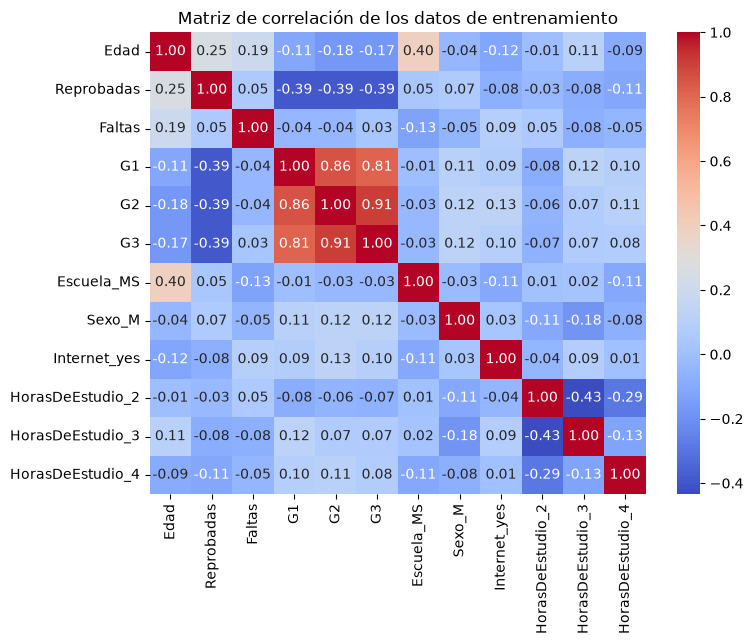

In [82]:
correlacion = train_limpio.select_dtypes(include="number").corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlacion,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Matriz de correlación de los datos de entrenamiento")
plt.show()

[GRÁFICA 1.] Matriz de correlación de los datos de entrenamiento entre las variables después de la limpieza de datos.

## Selección de características
Con el objetivo de construir un modelo con únicamente las variables más relevantes, se utilizaron dos métodos de selección de características: selección hacia adelante y selección hacia atrás.

Para ambos métodos se utilizó regresión lineal y validación cruzada, tomando el coeficiente de R^2 ajustada como criterio para la comparación de los modelos. Este proceso de selección se realizó exclusivamente utilizando los datos de entrenamiento.

### Selección hacia adelante
La selección hacia adelante comienza con un conjunto reducido de características y agrega aquellas que permiten mejorar el desempeño del modelo. Mediante este procedimiento fueron seleccionadas las variables Faltas, G1, G2, Sexo_M y HorasDeEstudio_3, representadas en la Tabla 10.

El resultado muestra que las dos calificaciones anteriores (G1 y G2) fueron consideradas relevantes para predecir la calificación final. 

In [119]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector

X_train = train_limpio.drop(columns=["G3"])
y_train = train_limpio["G3"]
modelo = LinearRegression()

selector = SequentialFeatureSelector(modelo,n_features_to_select="auto",direction="forward",scoring="r2",cv=5)
selector.fit(X_train, y_train)
variables_adelante = X_train.columns[selector.get_support()]

tabla_seleccion = pd.DataFrame({"Variable seleccionada": variables_adelante})
(tabla_seleccion.style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]).set_caption("[TABLA 10]. Características seleccionadas mediante selección hacia adelante."))

Variable seleccionada
Faltas
G1
G2
Sexo_M
HorasDeEstudio_3


### Selección hacia atrás
La eliminación hacia atrás comienza utilizando otdas las variables disponibles y elimina las que aportan un menor desempeño en el modelo. Las variables que se conservaron fueron: Edad, Faltas, G1, G2, Escuela_MS y Sexo_M, observadas en la Tabla 11.

Al comparar ambas selecciones, se observa que Faltas, G1, G2 y Sexo_M fueron seleccionadas por los dos métodos. Además, la presencia de G1 y G2 en ambas selecciones coinicide con la relación observada en la matriz de correlación. Aunque ambas variables presentan cierta redundancia entre ellas, los métodos de selección determinaron que conservar ambas variables proporciona información útil al modelo.

In [120]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector

modelo = LinearRegression()
selector_atras = SequentialFeatureSelector(modelo,n_features_to_select="auto",direction="backward",scoring="r2",cv=5)
selector_atras.fit(X_train, y_train)
variables_atras = X_train.columns[selector_atras.get_support()]

tabla_atras = pd.DataFrame({"Variable seleccionada": variables_atras})

(tabla_atras.style.hide(axis="index").set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]).set_caption("[TABLA 11]. Características seleccionadas mediante eliminación hacia atrás."))

Variable seleccionada
Edad
Faltas
G1
G2
Escuela_MS
Sexo_M


## Entrenamiento y evaluación del modelo
Después de seleccionar las características, se entrenaron dos modelos de regresión lineal múltiple utilizando únicamente las variables identificadas por cada procedimiento.

### Entrenamiento del modelo con selección hacia adelante
El modelo correspondiente a la selección hacia adelante quedó compuesto por Faltas, G1, G2, Sexo_M y HorasDeEstudio_3.

Los coeficientes obtenidos se muestran en la Tabla 12, donde los valores obtenidos fueron Faltas = 0.0479, G1 = 0.1801, G2 = 0.9686, Sexo_M = 0.1444 y HorasDeEstudio_3 = 0.1328.

Entre las variables relacionadas con las calificaciones, G2 presentó el coeficiente de mayor magnitud. Manteniendo constantes las demás variables, un incremento de un punto en G2 se relaciona con un aumento aproximado de 0.97 puntos en la calificación final predicha. Por su parte, un incremento de un punto en G1 está asociado con aproximadamente 0.18 puntos adicionales en la predicción de G3, mientras se mantengan constantes las demás características.

In [125]:
X_train_adelante = train_limpio[variables_adelante].astype(float)
y_train = train_limpio["G3"].astype(float)

X_train_ad = np.column_stack((np.ones(len(X_train_adelante)),X_train_adelante.values))

coef_adelante = np.linalg.lstsq(X_train_ad,y_train.values,rcond=None)[0]

tabla_modelo_adelante = pd.DataFrame({"Característica": ["Intercepto"] + list(variables_adelante),"Coeficiente": coef_adelante})
(tabla_modelo_adelante.style.hide(axis="index").format({"Coeficiente": "{:.4f}"}).set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]).set_caption("[TABLA 12]. Características y coeficientes del modelo con selección hacia adelante."))

Característica,Coeficiente
Intercepto,-2.3299
Faltas,0.0479
G1,0.1801
G2,0.9686
Sexo_M,0.1444
HorasDeEstudio_3,0.1328


### Entrenamiento del modelo con selección hacia atrás
El modelo correspondiente a la selección hacia atrás utilizo Edad, Faltas, G1, G2, Escuela_MS y Sexo_M.

Los coeficientes obtenidos se muestran en la Tabla 13, donde los coeficientes obtenidos fueron Edad = -0.1571, Faltas = 0.0545, G1 = 0.1903, G2 = 0.9542, Escuela_MS = 0.3108 y Sexo_M = 0.1269.

Nuevamente, G2 presentó un coeficiente cercano a uno. Manteniendo constantes las demás variables, cada incremento de un punto en G2 está relacionado con aproximadamente 0.95 puntos adicionales en la calificación final predicha. En este modelo, Edad presentó una asociación negativa, mientras que G1, G2, Faltas, Escuela_MS y Sexo_M presentaron coeficientes positivos.

In [126]:
X_train_atras = train_limpio[variables_atras].astype(float)
X_train_at = np.column_stack((np.ones(len(X_train_atras)),X_train_atras.values))

coef_atras = np.linalg.lstsq(X_train_at,y_train.values,rcond=None)[0]

tabla_modelo_atras = pd.DataFrame({"Característica": ["Intercepto"] + list(variables_atras),"Coeficiente": coef_atras})
(tabla_modelo_atras.style.hide(axis="index").format({"Coeficiente": "{:.4f}"}).set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]).set_caption("[TABLA 13]. Características y coeficientes del modelo con selección hacia atrás."))

Característica,Coeficiente
Intercepto,0.2870
Edad,-0.1571
Faltas,0.0545
G1,0.1903
G2,0.9542
Escuela_MS,0.3108
Sexo_M,0.1268


## Evaluación y comparación de los modelos
La Tabla 14 compara el desempeño de los modelos obtenidos mediante selección hacia adelante y selección hacia atrás, tanto en los datos de entrenamiento como en los datos de prueba.

En los datos de entrenamiento, el modelo de selección hacia adelante obtuvo una R^2 de 0.8379 y una R^2 ajustada de 0.8353, mientras que el modelo de selección hacia atrás presentó una R^2 de 0.8393 y una R^2 ajustada de 0.8361. Los valores de la R^2 ajustada son muy similares a los valores de R^2, lo que indica que las variables seleccionadas aportan información útil al modelo y que el aumento en la cantidad de características no mejora su desempeño de manera significativa.

Al evaluar los modelos con las 79 observaciones del conjunto de prueba, la selección hacia adelante obtuvo una R^2 de 0.7911, un RMSE de 1.8303 y un MAE de 1.1781. Esto significa que el modelo explica aproximadamente el 79.1 % de la variabilidad de las calificaciones finales en datos que no fueron utilizados durante el entrenamiento. Por otra parte, el modelo de selección hacia atrás obtuvo una R^2 de 0.8014, un RMSE de 1.7847 y un MAE de 1.1508, explicando aproximadamente el 80.1 % de la variabilidad de G3 en los datos de prueba.

Al comparar ambos métodos, el modelo de selección hacia atrás presenta una R^2 y una R^2 ajustada ligeramente mayores, además de menores valores de RMSE y MAE en los datos de prueba. Por lo tanto, este modelo presenta el mejor desempeño predictivo de los dos evaluados. 

In [128]:
# Función para evaluar los modelos
def evaluar_modelo(y_real, y_pred, p=None):
    y_real = np.array(y_real)
    y_pred = np.array(y_pred)
    errores = y_real - y_pred
    mae = np.mean(np.abs(errores))
    rmse = np.sqrt(np.mean(errores ** 2))
    ss_res = np.sum(errores ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    r2_ajustada = None
    if p is not None:
        n = len(y_real)
        r2_ajustada = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    return r2, r2_ajustada, rmse, mae

p_ad = X_train_ad.shape[1] - 1
p_at = X_train_at.shape[1] - 1
pred_train_adelante = X_train_ad @ coef_adelante
pred_test_adelante = X_test_ad @ coef_adelante
pred_train_atras = X_train_at @ coef_atras
pred_test_atras = X_test_at @ coef_atras

# Modelo hacia adelante
r2_train_ad, r2aj_train_ad, rmse_train_ad, mae_train_ad = evaluar_modelo(y_train, pred_train_adelante, p_ad)
r2_test_ad, _, rmse_test_ad, mae_test_ad = evaluar_modelo(y_test, pred_test_adelante)

# Modelo hacia atrás
r2_train_at, r2aj_train_at, rmse_train_at, mae_train_at = evaluar_modelo(y_train, pred_train_atras, p_at)
r2_test_at, _, rmse_test_at, mae_test_at = evaluar_modelo(y_test, pred_test_atras)

# Tabla 
tabla_evaluacion = pd.DataFrame({"Modelo": ["Selección hacia adelante","Selección hacia atrás"],"R² Train": [r2_train_ad,r2_train_at],"R² ajustada Train": [r2aj_train_ad,r2aj_train_at],"R² Test": [r2_test_ad,r2_test_at],"RMSE Train": [rmse_train_ad,rmse_train_at],"RMSE Test": [rmse_test_ad,rmse_test_at],"MAE Train": [mae_train_ad,mae_train_at],"MAE Test": [mae_test_ad,mae_test_at]})
(tabla_evaluacion.style.hide(axis="index").format({"R² Train": "{:.4f}","R² ajustada Train": "{:.4f}","R² Test": "{:.4f}","RMSE Train": "{:.4f}","RMSE Test": "{:.4f}","MAE Train": "{:.4f}","MAE Test": "{:.4f}"}).set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]).set_caption("[TABLA 14]. Comparación del desempeño de los modelos en datos de entrenamiento y prueba."))

Modelo,R² Train,R² ajustada Train,R² Test,RMSE Train,RMSE Test,MAE Train,MAE Test
Selección hacia adelante,0.8379,0.8353,0.7911,1.8816,1.8303,1.1591,1.1781
Selección hacia atrás,0.8393,0.8361,0.8014,1.8737,1.7847,1.1792,1.1508


### Visualización del desempeño del modelo final
Para observar visualmente el desempeño del modelo obtenido mediante eliminación hacia atrás, se compararon las calificaciones reales del conjunto de prueba con las calificaciones generadas por el modelo. En la Gráfica 2, la línea diagonal representa una predicción, es decir, donde la calificación predicha sería exactamente igual a la calificación real.

La mayoría de las observaciones se encuentran relativamente cercanas a esta línea, especialmente para las calificaciones medias y altas. Esto indica que el modelo logra representar adecuadamente la tendencia general de los datos y realizar predicciones cercanas a las calificaciones reales para una gran parte de los estudiantes.

Sin embargo, también se observan errores mayores en algunos casos extremos, estos corresponden a observaciones poco frecuentes y atípicas dentro del conjunto de datos. Debido a que el modelo cuenta con menos información para representar este tipo de casos, las predicciones tienden a presentar un mayor error en estos puntos, lo cual se observa en la gráfica por su mayor distancia respecto a la línea de predicción.

En general, la gráfica coincide con las métricas obtenidas: el modelo presenta un buen desempeño para la mayoría de las observaciones, aunque todavía existen algunos estudiantes para los cuales el error de predicción es considerablemente mayor.

Con el fin de evitar fuga de datos, se tomaron diferentes medidas para evitarlo. Primeramente se realizó la separación entre entrenamiento y prueba antes de la limpieza y selección de características. Además, los valores utilizados para tratar los casos extremos de Faltas fueron calculados únicamente con los datos de entrenamiento. 

El mismo límite obtenido durante el entrenamiento fue posteriormente aplicado al conjunto de prueba.  De igual manera, la matriz de correlación utilizada para analizar las relaciones entre variables y los métodos de selección de características fueron calculados utilizando únicamente los datos de entrenamiento. La selección hacia adelante y la eliminación hacia atrás también utilizaron validación cruzada únicamente dentro de este conjunto.

Finalmente, los coeficientes de los modelos fueron ajustados utilizando los datos de entrenamiento y el conjunto de prueba fue utilizado para evaluar su capacidad predictiva.

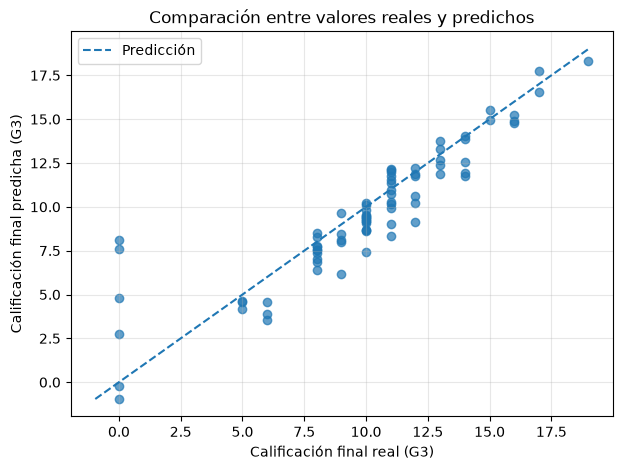

In [129]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, pred_test_atras, alpha=0.7)

limite_min = min(y_test.min(), pred_test_atras.min())
limite_max = max(y_test.max(), pred_test_atras.max())

plt.plot([limite_min, limite_max],[limite_min, limite_max],linestyle="--",label="Predicción")
plt.xlabel("Calificación final real (G3)")
plt.ylabel("Calificación final predicha (G3)")
plt.title("Comparación entre valores reales y predichos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

[GRÁFICA 2.] Comparación entre valores reales y predichos.

## Conclusiones
A partir del análisis realizado fue posible desarrollar un modelo de regresión lineal múltiple para predecir la calificación final G3 a partir de diferentes características académicas y demográficas de los estudiantes.

La etapa de preparación de los datos fue importante debido a que el conjunto contenía variables categóricas y posibles valores atípicos. El análisis mostró que un valor identificado estadísticamente como atípico no necesariamente debe eliminarse, ya que algunos de estos valores son posibles dentro conjunto de datos. Por esta razón, se realizó un tratamiento sobre los valores extremos de Faltas.

El análisis de correlación mostró que G1 y principalmente G2 presentan las relaciones más fuertes con la calificación final. También se identificó una correlación elevada entre estas dos características, lo que indica cierta redundancia de información. A pesar de esto, ambos métodos de selección conservaron las dos variables, lo que indica que ambas continúan aportando información útil para la predicción. La selección hacia adelante y la selección hacia atrás presentaron un desempeño similar en los datos de prueba. Aunque el modelo obtenido mediante selección hacia atrás presentó los mejores resultados, con un R^2 de 0.8014, un RMSE de 1.7847 y un MAE de 1.1508.

La visualización de los valores reales y predichos mostró que el modelo representa adecuadamente la tendencia general de las calificaciones, aunque presenta mayores dificultades para algunos valores extremos, principalmente cuando la calificación final real es cero.

En general, los resultados muestran la importancia de preparar correctamente los datos y seleccionar las características antes de construir un modelo predictivo. Utilizar todas las variables disponibles no necesariamente produce el mejor modelo, mientras que un proceso de selección permite reducir la cantidad de características manteniendo una buena capacidad de predicción.

Entre las principales limitaciones se encuentra que el modelo supone una relación lineal entre las variables y puede generar predicciones fuera del rango real de calificaciones. Como trabajo futuro, se podrían probar otros métodos de selección de variables y modelos diferentes para comparar si ofrecen mejores resultados.

## Bibliografía
Cortez, P. (2008). Student performance [Conjunto de datos]. UCI Machine Learning Repository. https://doi.org/10.24432/C5TG7T

OpenAI. (2026). ChatGPT (GPT-5.6 Sol) [Modelo de lenguaje grande]. ChatGPT